In [33]:
import numpy as np
import matplotlib.pyplot as plt
from memory_profiler import memory_usage
import time

In [34]:
def objective(x):
    return np.sum(x**2)

In [35]:
R = 5
def constraint(x, r = R):
    return np.linalg.norm(x) <= r

In [36]:
def oracle(x):
    if not constraint(x):
        x = x/np.linalg.norm(x) * R
    
    return x

In [37]:
def diff(func, x, epsilon = 1e-6):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x0, x1 = x.copy(), x.copy()
        x0[i] += epsilon
        x1[i] -= epsilon
        grad[i] = (func(x0) - func(x1))/(2*epsilon)
    return grad

In [38]:
def step (x, lr = 0.01):
    grad = diff(objective, x)
    x = x - lr*grad
    x = oracle(x)
    return x

In [39]:
def opti(x0, lr = 0.01, T = 200):
    x = x0.copy()
    history = []
    trajectory = []
    for t in range(T):
        x = step(x)
        history.append(objective(x))
        trajectory.append(x.copy())
    
    return x, history, trajectory


In [40]:
x0 = np.array([8.0, 6.0])

solution, history, trajectory = opti(x0)

print("Final Solution:", solution)
print("Final Cost:", objective(solution))
print("Feasible:", constraint(solution))

Final Solution: [0.07178754 0.05384065]
Final Cost: 0.008052266393794364
Feasible: True


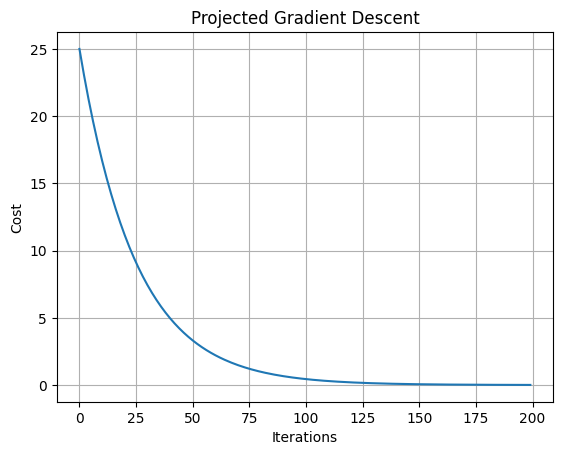

In [41]:
plt.plot(history)

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.title("Projected Gradient Descent")

plt.grid(True)

plt.show()

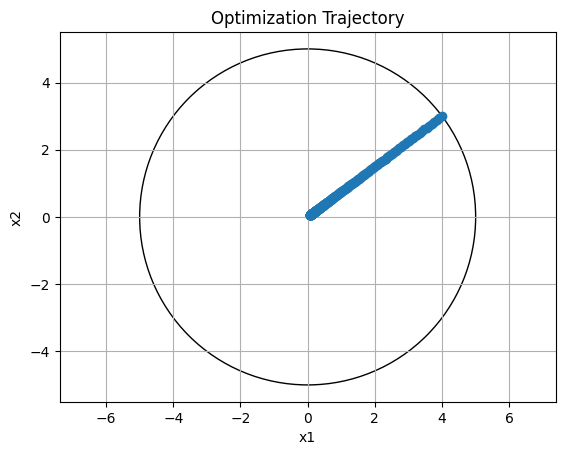

In [42]:
trajectory = np.array(trajectory)

plt.plot(trajectory[:,0], trajectory[:,1], marker='o')

circle = plt.Circle((0,0), R, fill=False)

plt.gca().add_patch(circle)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Optimization Trajectory")

plt.axis('equal')

plt.grid(True)

plt.show()